# Análise Exploratória — Despesas Liquidadas (PE)

**Fonte:** `ts_liquidado.parquet`  
**Período:** 2008 – Jun/2025  
**Objeto:** Despesas liquidadas por Ação orçamentária do Estado de Pernambuco  

---

## Roteiro

| Seção | Objetivo |
|---|---|
| 1. Carregamento e visão geral | Shape, tipos, nulos, primeiros registros |
| 2. Cobertura temporal | Distribuição ano/mês; tratamento do Mês 13 |
| 3. Análise dimensional | UO, Ação, Grupo de Despesa, RREO, Fonte |
| 4. Distribuição dos valores | Assimetria, negativos, zeros, outliers |
| 5. Construção das séries | Quantidade, comprimento, sinal |
| 6. Sazonalidade e tendência | Perfil mensal, tendência anual |
| 7. Top séries | Maiores despesas; análise de concentração |
| 8. Qualificação para modelagem | Séries que passam nos critérios de filtragem |

In [1]:
import sys
from pathlib import Path

ROOT = Path().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import display

matplotlib.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.facecolor': 'white',
    'axes.facecolor': '#F4F6F9',
    'axes.grid': True,
    'grid.color': 'white',
})

AZUL  = '#1B3A5C'
VERDE = '#27AE60'
VERM  = '#C0392B'
LARAN = '#E67E22'
ROXO  = '#8E44AD'

print('Setup OK')

Setup OK


---
## 1. Carregamento e Visão Geral

In [2]:
from config import CAMINHO_PARQUET

df_raw = pd.read_parquet(CAMINHO_PARQUET)

print(f'Shape: {df_raw.shape[0]:,} linhas × {df_raw.shape[1]} colunas')
print(f'Período: {df_raw["Ano"].min()} – {df_raw["Ano"].max()}')
print(f'Meses distintos: {sorted(df_raw["Mês"].unique())}')
print()
display(df_raw.dtypes.to_frame('dtype').T)
display(df_raw.isnull().sum().to_frame('nulos').T)

Shape: 331,779 linhas × 14 colunas
Período: 2008 – 2025
Meses distintos: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13)]



,Ano,Mês,UO_Cód_Ação,UO_Nome_Ação,Ação_Cód,Ação_Nome,Subação_Cód,Subação_Nome,Grupo_Despesa_Cód,RREO,Fonte_Detalhada_Cód,Fonte_Det_Cód_Harm,Fonte_Det_Nome_Harm,Valor_Liquidado
dtype,int64,int64,float64,str,int64,str,str,str,int64,str,int64,int64,str,float64


,Ano,Mês,UO_Cód_Ação,UO_Nome_Ação,Ação_Cód,Ação_Nome,Subação_Cód,Subação_Nome,Grupo_Despesa_Cód,RREO,Fonte_Detalhada_Cód,Fonte_Det_Cód_Harm,Fonte_Det_Nome_Harm,Valor_Liquidado
nulos,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [3]:
display(df_raw.head(5))

,Ano,Mês,UO_Cód_Ação,UO_Nome_Ação,Ação_Cód,Ação_Nome,Subação_Cód,Subação_Nome,Grupo_Despesa_Cód,RREO,Fonte_Detalhada_Cód,Fonte_Det_Cód_Harm,Fonte_Det_Nome_Harm,Valor_Liquidado
0,2008,1,1.0,Assembleia Legislativa - Administração Direta,665,FORMAÇÃO CONTINUADA DA ESCOLA DO LEGISLATIVO,0000,OUTRAS MEDIDAS,3,DEMAIS DESPESAS CORRENTES,101000000,101000000,Recursos Ordinários - Adm. Direta,900.00
1,2008,1,1.0,Assembleia Legislativa - Administração Direta,667,CONTRIBUIÇÕES PATRONAIS DA ASSEMBLEIA LEGISLAT...,0000,OUTRAS MEDIDAS,1,PESSOAL E ENCARGOS SOCIAIS,101000000,500000000,RECURSOS NÃO VINCULADOS DE IMPOSTOS,299499.71
2,2008,1,1.0,Assembleia Legislativa - Administração Direta,668,CONCESSÃO DE AUXÍLIO ALIMENTAÇÃO A SERVIDORES ...,0000,OUTRAS MEDIDAS,3,DEMAIS DESPESAS CORRENTES,101000000,500000000,RECURSOS NÃO VINCULADOS DE IMPOSTOS,209250.00
3,2008,1,1.0,Assembleia Legislativa - Administração Direta,671,GESTÃO ADMINISTRATIVA DAS AÇÕES DA ALEPE,0000,OUTRAS MEDIDAS,1,PESSOAL E ENCARGOS SOCIAIS,101000000,101000000,Recursos Ordinários - Adm. Direta,7093457.82
4,2008,1,1.0,Assembleia Legislativa - Administração Direta,671,GESTÃO ADMINISTRATIVA DAS AÇÕES DA ALEPE,0000,OUTRAS MEDIDAS,3,DEMAIS DESPESAS CORRENTES,101000000,101000000,Recursos Ordinários - Adm. Direta,1901088.10


In [4]:
# Estatísticas descritivas das colunas numéricas
display(
    df_raw[['Ano', 'Mês', 'Valor_Liquidado']]
    .describe(percentiles=[.01, .05, .25, .50, .75, .95, .99])
    .style.format('{:,.2f}')
)

,Ano,Mês,Valor_Liquidado
count,"331,779.00","331,779.00","331,779.00"
mean,"2,016.71",7.01,"1,715,068.91"
std,4.94,3.32,"11,521,601.83"
min,"2,008.00",1.00,"-105,839,674.66"
1%,"2,008.00",1.00,-0.05
5%,"2,009.00",2.00,681.71
25%,"2,013.00",4.00,"12,486.06"
50%,"2,017.00",7.00,"75,634.65"
75%,"2,021.00",10.00,"448,818.75"
95%,"2,024.00",12.00,"5,360,016.24"


---
## 2. Cobertura Temporal

In [5]:
# Registros com Mês == 13 (ajustes contábeis anuais)
mes13 = df_raw[df_raw['Mês'] == 13]
print(f'Registros com Mês=13: {len(mes13):,} ({len(mes13)/len(df_raw)*100:.2f}% do total)')
print(f'Valor liquidado nesses registros: R$ {mes13["Valor_Liquidado"].sum():,.2f}')
print(f'Anos com Mês=13: {sorted(mes13["Ano"].unique())}')

Registros com Mês=13: 71 (0.02% do total)
Valor liquidado nesses registros: R$ 10,887,757.67
Anos com Mês=13: [np.int64(2011), np.int64(2012)]


In [6]:
# Base filtrada (sem Mês 13)
df = df_raw[df_raw['Mês'] != 13].copy()
df['Periodo'] = pd.to_datetime(
    df['Ano'].astype(str) + '-' + df['Mês'].astype(str).str.zfill(2)
).dt.to_period('M')

print(f'Base filtrada: {len(df):,} registros')
print(f'Cobertura: {df["Periodo"].min()} → {df["Periodo"].max()}')
print(f'Total de períodos mensais únicos: {df["Periodo"].nunique()}')

Base filtrada: 331,708 registros
Cobertura: 2008-01 → 2025-06
Total de períodos mensais únicos: 210


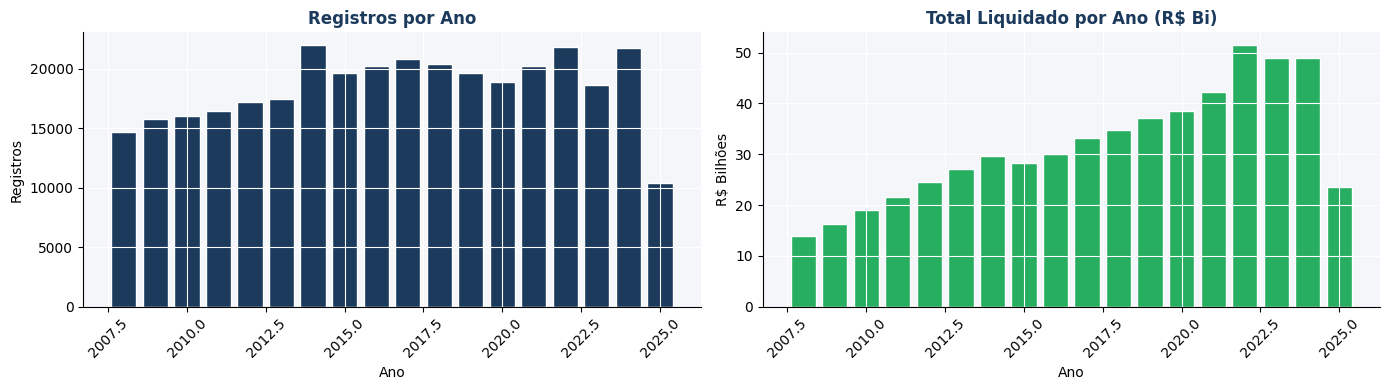

Ano,N_Registros,Total_Liquidado
2008,"14,674","R$ 13,845,690,425"
2009,"15,799","R$ 16,347,690,704"
2010,"15,984","R$ 18,971,360,516"
2011,"16,458","R$ 21,505,429,641"
2012,"17,156","R$ 24,469,249,983"
2013,"17,426","R$ 27,132,753,503"
2014,"21,940","R$ 29,663,830,413"
2015,"19,628","R$ 28,203,579,245"
2016,"20,230","R$ 30,092,027,994"
2017,"20,807","R$ 33,291,006,994"


In [7]:
# Volume de registros por ano
por_ano = df.groupby('Ano').agg(
    N_Registros=('Valor_Liquidado', 'count'),
    Total_Liquidado=('Valor_Liquidado', 'sum'),
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(por_ano['Ano'], por_ano['N_Registros'], color=AZUL, edgecolor='white')
axes[0].set_title('Registros por Ano', fontweight='bold', color=AZUL)
axes[0].set_xlabel('Ano'); axes[0].set_ylabel('Registros')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(por_ano['Ano'], por_ano['Total_Liquidado'] / 1e9, color=VERDE, edgecolor='white')
axes[1].set_title('Total Liquidado por Ano (R$ Bi)', fontweight='bold', color=AZUL)
axes[1].set_xlabel('Ano'); axes[1].set_ylabel('R$ Bilhões')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

display(por_ano.style.format({'N_Registros': '{:,}', 'Total_Liquidado': 'R$ {:,.0f}'}).hide(axis='index'))

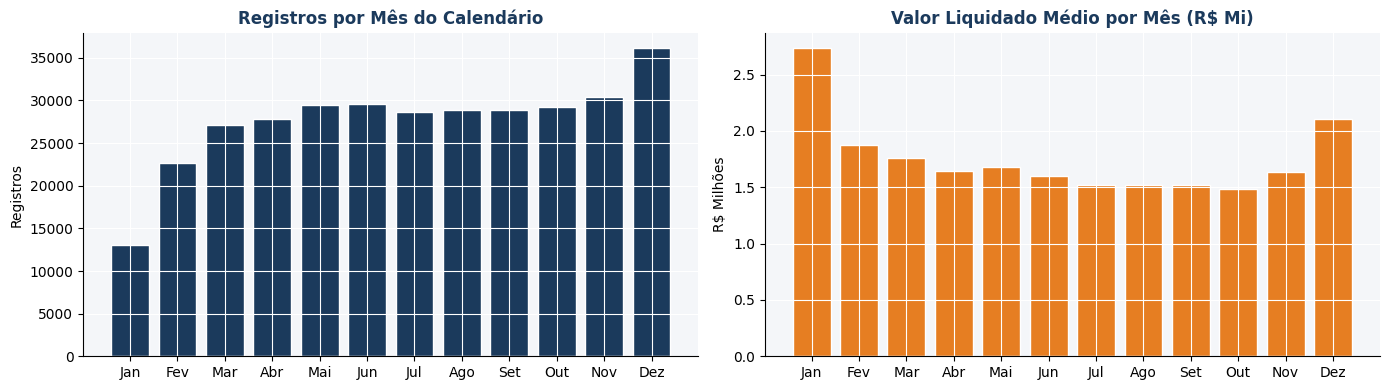

In [8]:
# Perfil de registros por mês do calendário
por_mes = df.groupby('Mês')['Valor_Liquidado'].agg(['count', 'sum', 'mean']).reset_index()
meses_nome = ['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(meses_nome, por_mes['count'], color=AZUL, edgecolor='white')
axes[0].set_title('Registros por Mês do Calendário', fontweight='bold', color=AZUL)
axes[0].set_ylabel('Registros')

axes[1].bar(meses_nome, por_mes['mean'] / 1e6, color=LARAN, edgecolor='white')
axes[1].set_title('Valor Liquidado Médio por Mês (R$ Mi)', fontweight='bold', color=AZUL)
axes[1].set_ylabel('R$ Milhões')

plt.tight_layout()
plt.show()

---
## 3. Análise Dimensional

In [9]:
dims = {
    'UO_Nome_Ação': 'Unidade Orçamentária',
    'Ação_Cód': 'Ação',
    'Grupo_Despesa_Cód': 'Grupo de Despesa',
    'RREO': 'Classificação RREO',
    'Fonte_Det_Nome_Harm': 'Fonte Detalhada Harmonizada',
}

print('Cardinalidade das dimensões:')
for col, label in dims.items():
    print(f'  {label:35s}: {df[col].nunique():>6,} valores únicos')

Cardinalidade das dimensões:
  Unidade Orçamentária               :     93 valores únicos
  Ação                               :  2,564 valores únicos
  Grupo de Despesa                   :      6 valores únicos
  Classificação RREO                 :      7 valores únicos
  Fonte Detalhada Harmonizada        :  2,492 valores únicos


In [10]:
# Grupos de Despesa
gd = (
    df.groupby(['Grupo_Despesa_Cód', 'RREO'])['Valor_Liquidado']
    .sum().reset_index()
    .sort_values('Valor_Liquidado', ascending=False)
)
gd['Pct'] = gd['Valor_Liquidado'] / gd['Valor_Liquidado'].sum() * 100

print('Distribuição por Grupo de Despesa / RREO (todo o período):')
display(
    gd.style
    .format({'Valor_Liquidado': 'R$ {:,.0f}', 'Pct': '{:.2f}%'})
    .hide(axis='index')
)

Distribuição por Grupo de Despesa / RREO (todo o período):


Grupo_Despesa_Cód,RREO,Valor_Liquidado,Pct
1,PESSOAL E ENCARGOS SOCIAIS,"R$ 292,446,240,165",51.40%
3,DEMAIS DESPESAS CORRENTES,"R$ 151,941,008,677",26.70%
3,TRANSF MUN,"R$ 62,838,635,560",11.04%
4,INVESTIMENTOS,"R$ 28,441,650,512",5.00%
6,AMORTIZAÇÃO DA DÍVIDA,"R$ 14,583,353,627",2.56%
2,ENCARGOS DA DÍVIDA,"R$ 9,874,300,327",1.74%
5,INVERSÕES FINANCEIRAS,"R$ 8,887,769,746",1.56%


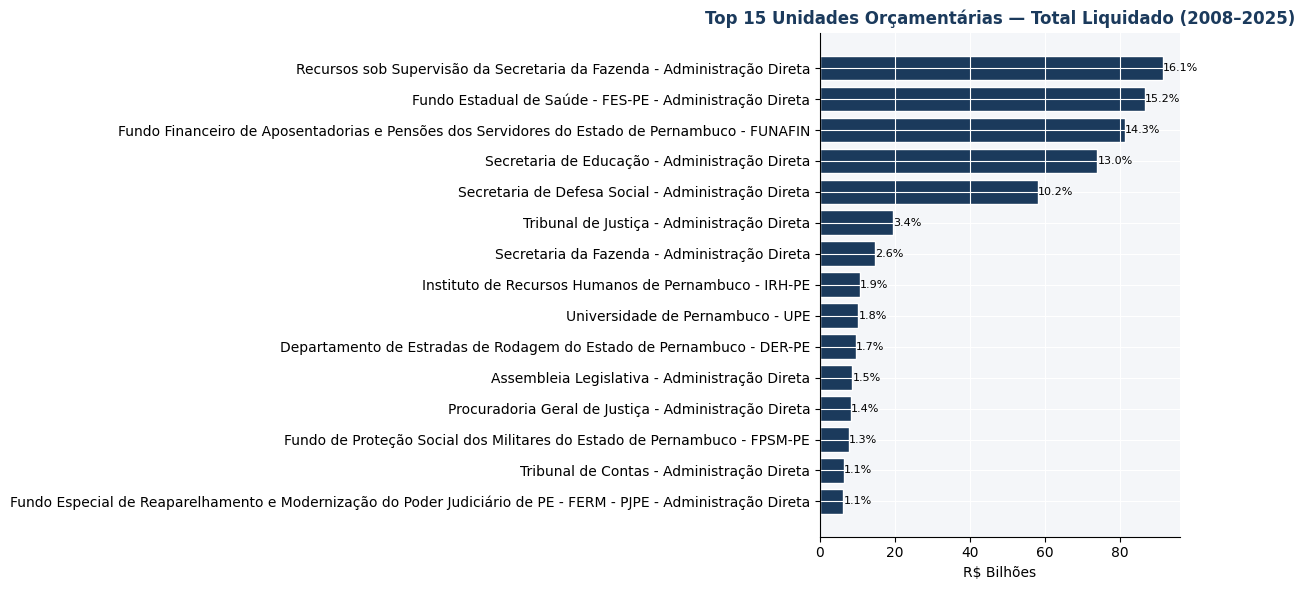

In [11]:
# Top 15 Unidades Orçamentárias por valor total
top_uo = (
    df.groupby('UO_Nome_Ação')['Valor_Liquidado']
    .sum().sort_values(ascending=False)
    .head(15).reset_index()
)
top_uo['Pct'] = top_uo['Valor_Liquidado'] / df['Valor_Liquidado'].sum() * 100

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top_uo['UO_Nome_Ação'][::-1], top_uo['Valor_Liquidado'][::-1] / 1e9,
               color=AZUL, edgecolor='white')
ax.set_xlabel('R$ Bilhões')
ax.set_title('Top 15 Unidades Orçamentárias — Total Liquidado (2008–2025)',
             fontweight='bold', color=AZUL)
for bar, pct in zip(bars, top_uo['Pct'][::-1]):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{pct:.1f}%', va='center', fontsize=8)
plt.tight_layout()
plt.show()

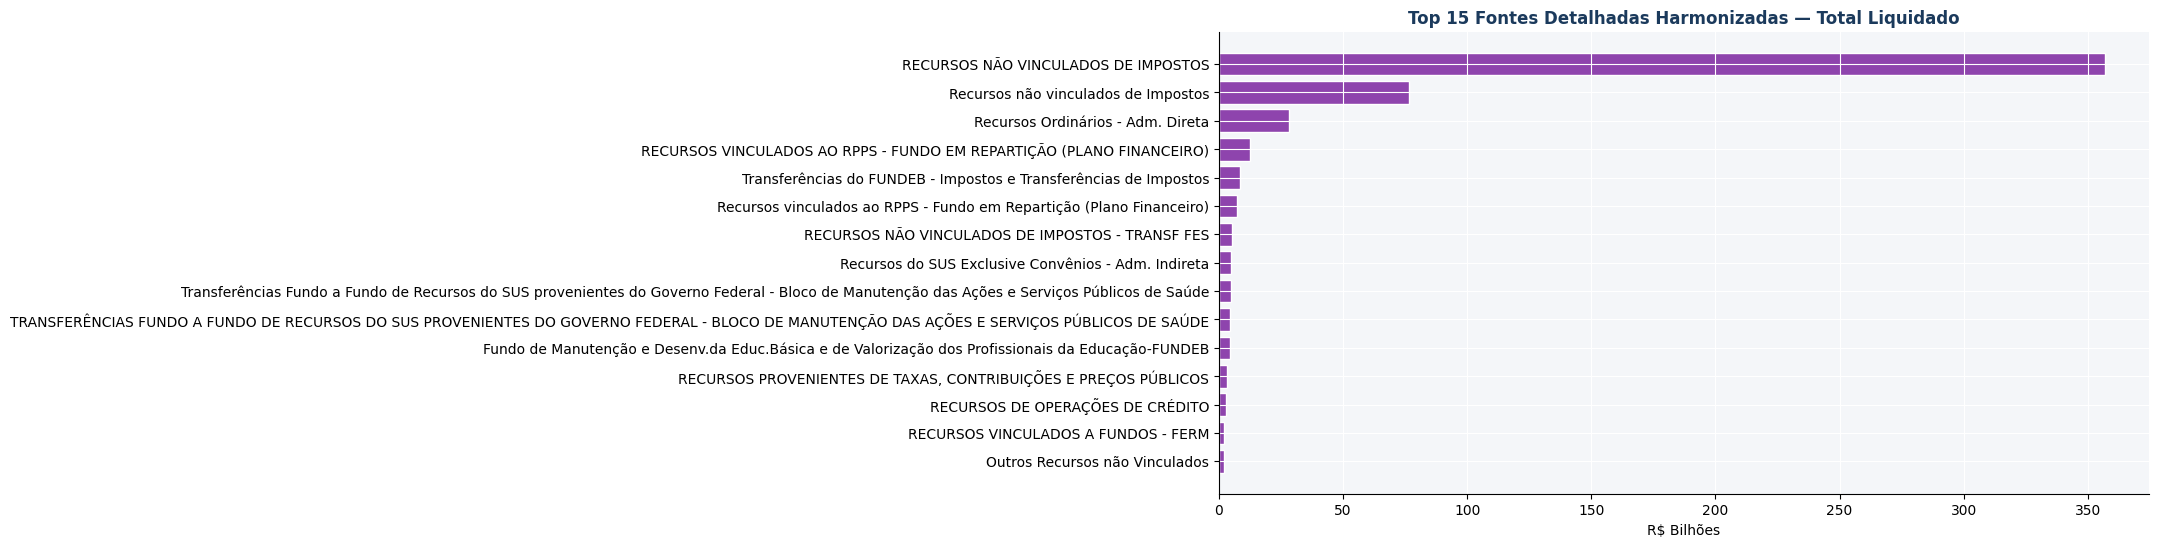

In [12]:
# Top 15 Fontes Detalhadas por valor total
top_fonte = (
    df.groupby('Fonte_Det_Nome_Harm')['Valor_Liquidado']
    .sum().sort_values(ascending=False)
    .head(15).reset_index()
)
top_fonte['Pct'] = top_fonte['Valor_Liquidado'] / df['Valor_Liquidado'].sum() * 100

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(top_fonte['Fonte_Det_Nome_Harm'][::-1],
        top_fonte['Valor_Liquidado'][::-1] / 1e9,
        color=ROXO, edgecolor='white')
ax.set_xlabel('R$ Bilhões')
ax.set_title('Top 15 Fontes Detalhadas Harmonizadas — Total Liquidado',
             fontweight='bold', color=AZUL)
plt.tight_layout()
plt.show()

---
## 4. Distribuição dos Valores Liquidados

In [13]:
vals = df['Valor_Liquidado']

negativos = (vals < 0).sum()
zeros     = (vals == 0).sum()
positivos = (vals > 0).sum()

print('Composição dos valores:')
print(f'  Positivos : {positivos:>8,} ({positivos/len(vals)*100:.2f}%)')
print(f'  Zeros     : {zeros:>8,} ({zeros/len(vals)*100:.2f}%)')
print(f'  Negativos : {negativos:>8,} ({negativos/len(vals)*100:.2f}%)')
print(f'\n  Min  : R$ {vals.min():>18,.2f}')
print(f'  Max  : R$ {vals.max():>18,.2f}')
print(f'  Soma : R$ {vals.sum():>18,.2f}')
print(f'  Média: R$ {vals.mean():>18,.2f}')
print(f'  Mediana: R$ {vals.median():>16,.2f}')

Composição dos valores:
  Positivos :  325,509 (98.13%)
  Zeros     :    2,807 (0.85%)
  Negativos :    3,392 (1.02%)

  Min  : R$    -105,839,674.66
  Max  : R$     591,960,064.93
  Soma : R$ 569,012,958,614.50
  Média: R$       1,715,403.18
  Mediana: R$        75,656.29


In [15]:
# Valores negativos: quais grupos de despesa?
if negativos > 0:
    df_neg = df[df['Valor_Liquidado'] < 0]
    print(f'Registros negativos por Grupo de Despesa:')
    display(
        df_neg.groupby(['Grupo_Despesa_Cód', 'RREO'])
        .agg(N=('Valor_Liquidado', 'count'),
             Total=('Valor_Liquidado', 'sum'))
        .sort_values('Total')
        .style.format({'N': '{:,}', 'Total': 'R$ {:,.0f}'})
    )

Registros negativos por Grupo de Despesa:


,,N,Total
Grupo_Despesa_Cód,RREO,,
1,PESSOAL E ENCARGOS SOCIAIS,216,"R$ -497,376,787"
3,DEMAIS DESPESAS CORRENTES,"2,281","R$ -426,365,392"
4,INVESTIMENTOS,809,"R$ -291,386,482"
5,INVERSÕES FINANCEIRAS,82,"R$ -167,566,209"
6,AMORTIZAÇÃO DA DÍVIDA,2,"R$ -520,020"
2,ENCARGOS DA DÍVIDA,2,"R$ -235,240"


---
## 5. Construção e Qualidade das Séries Temporais

In [16]:
from utils.preprocessing import carregar_dados, construir_series, filtrar_series, classificar_sinal
from config import FIM_SERIE, MIN_SERIE

df_prep   = carregar_dados()
series_all = construir_series(df_prep)
series_val, excluidas = filtrar_series(series_all)

print(f'Total de séries construídas  : {len(series_all):>6,}')
print(f'Séries válidas (fim={FIM_SERIE}): {len(series_val):>6,}')
print(f'Séries excluídas             : {len(excluidas):>6,}')
print()
motivos = {}
for _, motivo in excluidas:
    chave = motivo.split('(')[0].strip()[:40]
    motivos[chave] = motivos.get(chave, 0) + 1
print('Motivos de exclusão:')
for m, c in sorted(motivos.items(), key=lambda x: -x[1]):
    print(f'  {m}: {c:,}')

Total de séries construídas  :  2,564
Séries válidas (fim=2025-06):    464
Séries excluídas             :  2,100

Motivos de exclusão:
  último período 2011-12 ≠ 2025-06: 450
  último período 2023-12 ≠ 2025-06: 224
  último período 2008-12 ≠ 2025-06: 187
  último período 2019-12 ≠ 2025-06: 114
  último período 2012-12 ≠ 2025-06: 52
  último período 2022-12 ≠ 2025-06: 47
  último período 2010-12 ≠ 2025-06: 45
  último período 2009-12 ≠ 2025-06: 29
  último período 2016-12 ≠ 2025-06: 29
  último período 2024-12 ≠ 2025-06: 29
  último período 2023-03 ≠ 2025-06: 29
  último período 2011-11 ≠ 2025-06: 27
  último período 2013-12 ≠ 2025-06: 26
  último período 2014-12 ≠ 2025-06: 24
  último período 2018-12 ≠ 2025-06: 23
  último período 2015-12 ≠ 2025-06: 20
  último período 2019-11 ≠ 2025-06: 20
  último período 2011-10 ≠ 2025-06: 20
  último período 2011-09 ≠ 2025-06: 17
  último período 2025-05 ≠ 2025-06: 17
  série curta: 17
  último período 2008-11 ≠ 2025-06: 16
  último período 2020-12

Estatísticas do comprimento das séries válidas:
count    464.000000
mean     110.536638
std       65.202416
min       10.000000
25%       54.000000
50%      119.000000
75%      162.000000
max      210.000000


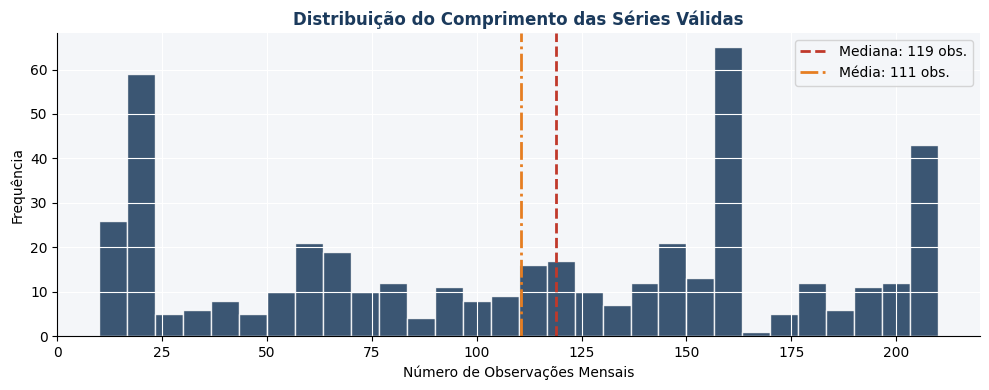

In [17]:
# Comprimento das séries válidas
comprimentos = pd.Series({k: len(v) for k, v in series_val.items()}, name='Comprimento')

print('Estatísticas do comprimento das séries válidas:')
print(comprimentos.describe().to_string())

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(comprimentos, bins=30, color=AZUL, edgecolor='white', alpha=0.85)
ax.axvline(comprimentos.median(), color=VERM, linewidth=2, linestyle='--',
           label=f'Mediana: {comprimentos.median():.0f} obs.')
ax.axvline(comprimentos.mean(), color=LARAN, linewidth=2, linestyle='-.',
           label=f'Média: {comprimentos.mean():.0f} obs.')
ax.set_title('Distribuição do Comprimento das Séries Válidas',
             fontweight='bold', color=AZUL)
ax.set_xlabel('Número de Observações Mensais')
ax.set_ylabel('Frequência')
ax.legend()
plt.tight_layout()
plt.show()

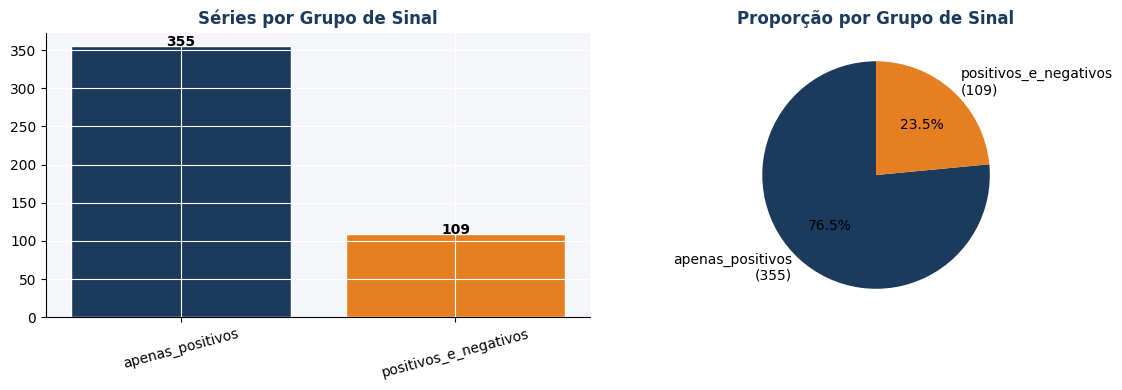

,Séries,Pct
Grupo_Sinal,,
apenas_positivos,355,76.5
positivos_e_negativos,109,23.5


In [18]:
# Classificação de sinal das séries válidas
sinais = pd.Series(
    {k: classificar_sinal(v) for k, v in series_val.items()},
    name='Grupo_Sinal'
)
contagem_sinais = sinais.value_counts()

cores_sinal = {
    'apenas_positivos'     : AZUL,
    'apenas_negativos'     : VERM,
    'positivos_e_negativos': LARAN,
}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

bars = axes[0].bar(
    contagem_sinais.index, contagem_sinais.values,
    color=[cores_sinal.get(s, AZUL) for s in contagem_sinais.index],
    edgecolor='white'
)
for bar, val in zip(bars, contagem_sinais.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.3, str(val),
                 ha='center', fontweight='bold')
axes[0].set_title('Séries por Grupo de Sinal', fontweight='bold', color=AZUL)
axes[0].tick_params(axis='x', rotation=15)

axes[1].pie(
    contagem_sinais.values,
    labels=[f'{s}\n({v})' for s, v in contagem_sinais.items()],
    colors=[cores_sinal.get(s, AZUL) for s in contagem_sinais.index],
    autopct='%1.1f%%', startangle=90,
)
axes[1].set_title('Proporção por Grupo de Sinal', fontweight='bold', color=AZUL)

plt.tight_layout()
plt.show()

display(contagem_sinais.to_frame('Séries').assign(Pct=lambda x: (x['Séries']/x['Séries'].sum()*100).round(1)))

---
## 6. Sazonalidade e Tendência

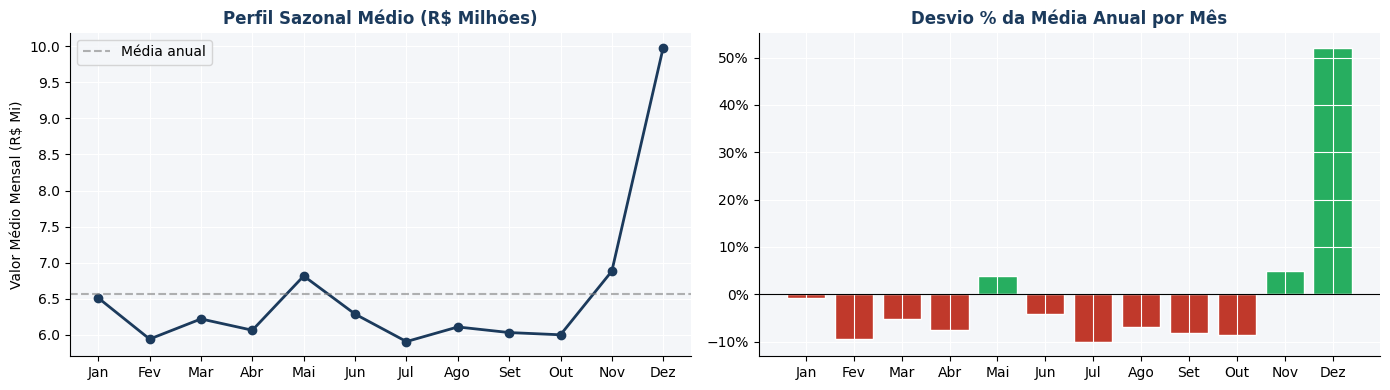

In [19]:
# Perfil mensal agregado (média de todas as séries válidas)
mensais = []
for cod, serie in series_val.items():
    df_s = serie.reset_index()
    df_s.columns = ['Periodo', 'Valor']
    df_s['Mes'] = df_s['Periodo'].dt.month
    mensais.append(df_s)

df_mensais = pd.concat(mensais, ignore_index=True)
perfil_mes = df_mensais.groupby('Mes')['Valor'].mean().reset_index()
perfil_mes_norm = perfil_mes.copy()
perfil_mes_norm['Valor_Norm'] = perfil_mes_norm['Valor'] / perfil_mes_norm['Valor'].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(meses_nome, perfil_mes['Valor'] / 1e6,
             marker='o', linewidth=2, color=AZUL)
axes[0].set_title('Perfil Sazonal Médio (R$ Milhões)', fontweight='bold', color=AZUL)
axes[0].set_ylabel('Valor Médio Mensal (R$ Mi)')
axes[0].axhline(perfil_mes['Valor'].mean() / 1e6, color='gray',
                linestyle='--', alpha=0.6, label='Média anual')
axes[0].legend()

axes[1].bar(meses_nome, perfil_mes_norm['Valor_Norm'] - 1,
            color=[VERDE if v >= 0 else VERM for v in (perfil_mes_norm['Valor_Norm'] - 1)],
            edgecolor='white')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Desvio % da Média Anual por Mês', fontweight='bold', color=AZUL)
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

plt.tight_layout()
plt.show()

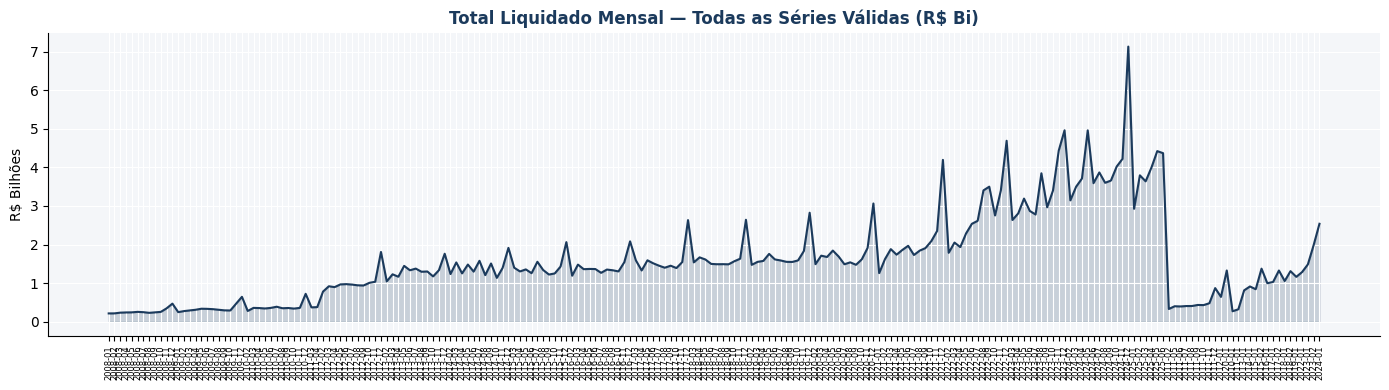

In [20]:
# Evolução do total liquidado mensal (todas as séries válidas agregadas)
df_todos = pd.concat(
    [s.rename(cod) for cod, s in series_val.items()], axis=1
).fillna(0)

total_mensal = df_todos.sum(axis=1)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(total_mensal.index.astype(str), total_mensal / 1e9,
        color=AZUL, linewidth=1.5)
ax.fill_between(total_mensal.index.astype(str), total_mensal / 1e9,
                alpha=0.2, color=AZUL)
ax.set_title('Total Liquidado Mensal — Todas as Séries Válidas (R$ Bi)',
             fontweight='bold', color=AZUL)
ax.set_ylabel('R$ Bilhões')
ax.tick_params(axis='x', rotation=90, labelsize=6)
plt.tight_layout()
plt.show()

---
## 7. Top Séries por Volume

Concentração: top 5 séries respondem por 25.1% do total
              top 20 séries respondem por 60.6% do total


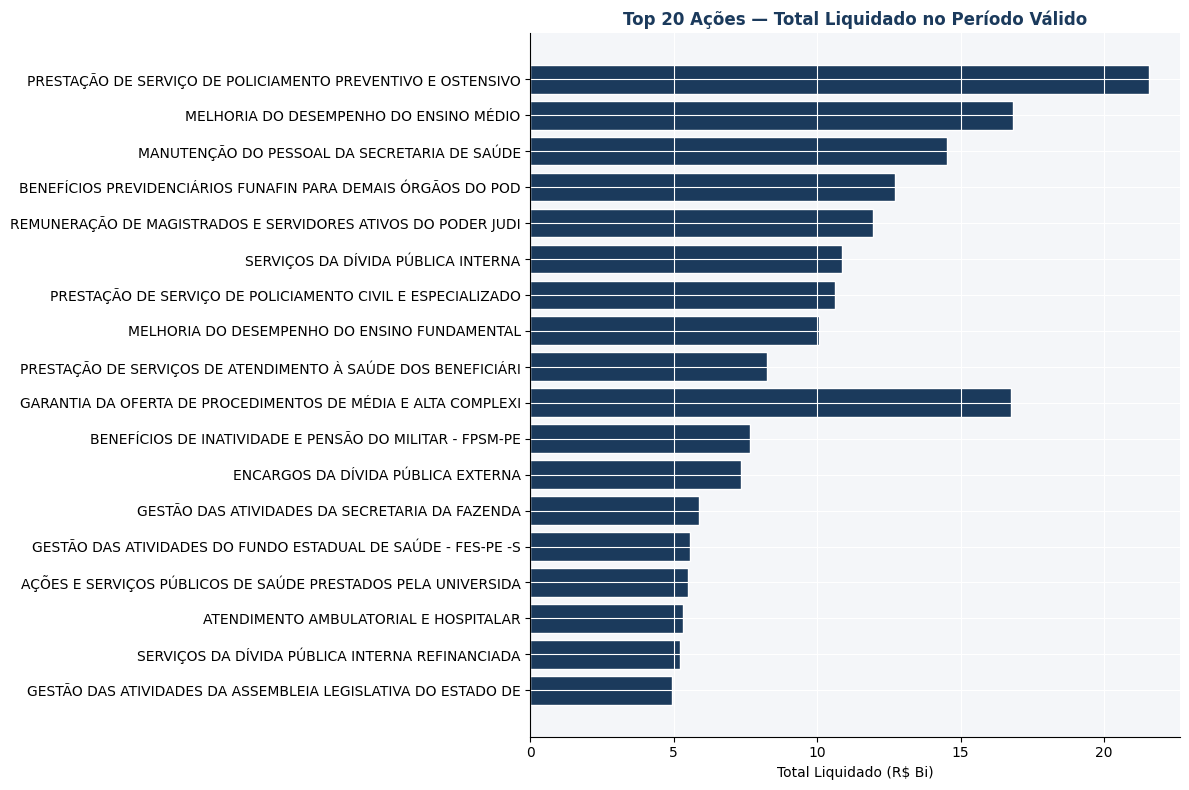

In [21]:
from utils.preprocessing import mapear_nomes

nomes = mapear_nomes(df_prep)

# Ranking por soma total
soma_series = pd.Series(
    {cod: serie.sum() for cod, serie in series_val.items()},
    name='Total'
).sort_values(ascending=False)

top20 = soma_series.head(20).reset_index()
top20.columns = ['Codigo', 'Total']
top20['Nome'] = top20['Codigo'].map(nomes).str[:60]
top20['Pct'] = top20['Total'] / soma_series.sum() * 100

print(f'Concentração: top 5 séries respondem por {top20["Pct"].head(5).sum():.1f}% do total')
print(f'              top 20 séries respondem por {top20["Pct"].sum():.1f}% do total')

fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(top20['Nome'][::-1], top20['Total'][::-1] / 1e9, color=AZUL, edgecolor='white')
ax.set_xlabel('Total Liquidado (R$ Bi)')
ax.set_title('Top 20 Ações — Total Liquidado no Período Válido',
             fontweight='bold', color=AZUL)
plt.tight_layout()
plt.show()

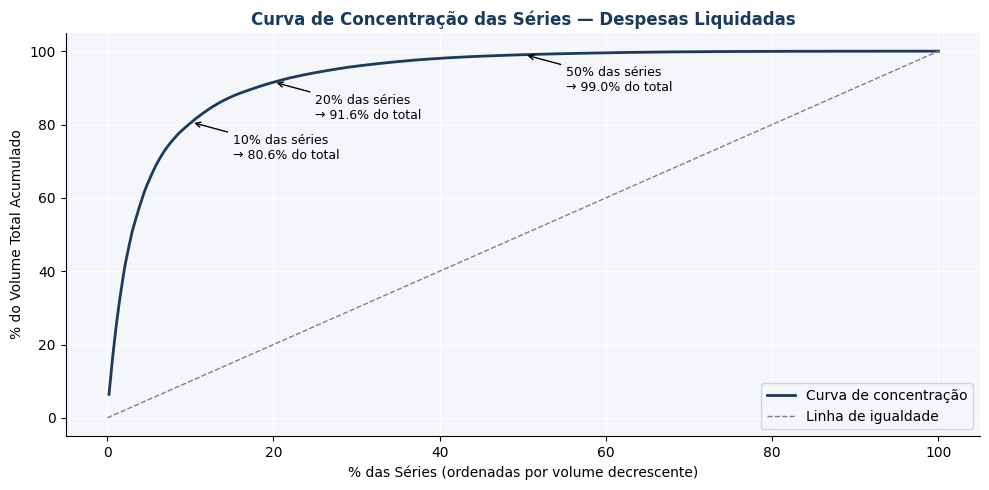

In [22]:
# Curva de Lorenz / concentração (Pareto)
somas_ord = soma_series.sort_values(ascending=False)
cum_pct   = somas_ord.cumsum() / somas_ord.sum() * 100
series_pct = np.arange(1, len(somas_ord)+1) / len(somas_ord) * 100

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(series_pct, cum_pct, color=AZUL, linewidth=2, label='Curva de concentração')
ax.plot([0, 100], [0, 100], color='gray', linestyle='--', linewidth=1, label='Linha de igualdade')

# Anotações
for pct_series, label in [(10, '10%'), (20, '20%'), (50, '50%')]:
    idx = int(pct_series / 100 * len(series_pct))
    if idx < len(cum_pct):
        val = cum_pct.iloc[idx]
        ax.annotate(f'{pct_series}% das séries\n→ {val:.1f}% do total',
                    xy=(series_pct[idx], val),
                    xytext=(series_pct[idx]+5, val-10),
                    arrowprops=dict(arrowstyle='->', color='black'),
                    fontsize=9)

ax.set_xlabel('% das Séries (ordenadas por volume decrescente)')
ax.set_ylabel('% do Volume Total Acumulado')
ax.set_title('Curva de Concentração das Séries — Despesas Liquidadas',
             fontweight='bold', color=AZUL)
ax.legend()
plt.tight_layout()
plt.show()

---
## 8. Qualificação para Modelagem

In [23]:
from utils.acf_analysis import analisar_serie
from utils.preprocessing import preparar_serie, dividir_serie
from config import MIN_TREINO

qualificacao = []
print(f'Analisando {len(series_val)} séries válidas ...')

for cod, serie in series_val.items():
    serie_pronta, grupo, shift = preparar_serie(serie)
    treino_vals, teste_vals, _, _, n_holdout, n_lags = dividir_serie(serie_pronta)
    n_treino = len(treino_vals)
    acf_info = analisar_serie(treino_vals)

    qualificacao.append({
        'Codigo'       : cod,
        'Nome'         : nomes.get(cod, '—')[:50],
        'Grupo_Sinal'  : grupo,
        'N_Total'      : len(serie),
        'N_Treino'     : n_treino,
        'N_Holdout'    : n_holdout,
        'N_Lags'       : acf_info['n_lags'],
        'LB_Pvalor'    : acf_info['lb_pvalor'],
        'Ruido_Branco' : acf_info['e_ruido_branco'],
        'Rodar_ML'     : n_treino >= MIN_TREINO,
    })

qual_df = pd.DataFrame(qualificacao)

n_rb   = qual_df['Ruido_Branco'].sum()
n_ml   = qual_df['Rodar_ML'].sum()
n_prev = (~qual_df['Ruido_Branco']).sum()

print(f'\nResumo:')
print(f'  Séries válidas            : {len(qual_df):>6,}')
print(f'  Ruído branco (LB)         : {n_rb:>6,} ({n_rb/len(qual_df)*100:.1f}%)')
print(f'  Serão previstas           : {n_prev:>6,} ({n_prev/len(qual_df)*100:.1f}%)')
print(f'  Com ML habilitado         : {n_ml:>6,} ({n_ml/len(qual_df)*100:.1f}%)')
print(f'  Apenas ARIMA (série curta): {(n_prev - n_ml):>6,}')

Analisando 464 séries válidas ...

Resumo:
  Séries válidas            :    464
  Ruído branco (LB)         :    170 (36.6%)
  Serão previstas           :    294 (63.4%)
  Com ML habilitado         :    430 (92.7%)
  Apenas ARIMA (série curta):   -136


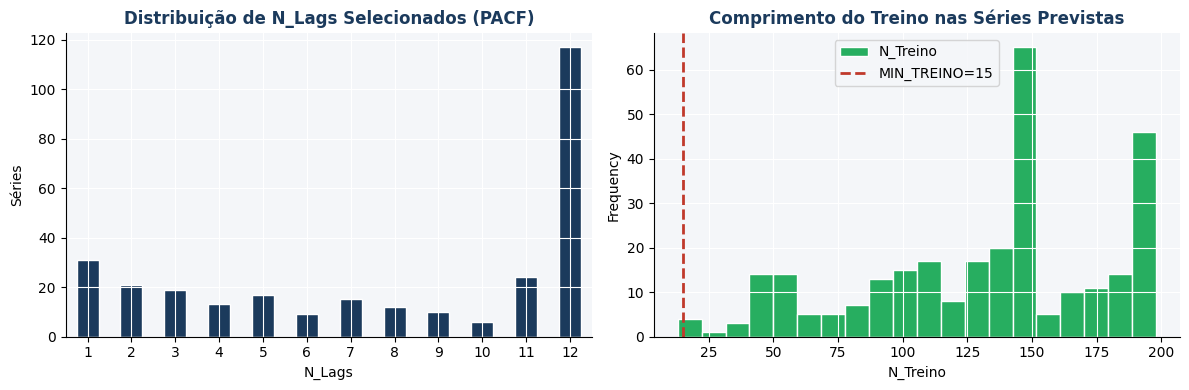

In [24]:
# Distribuição de lags selecionados
lags_validos = qual_df[~qual_df['Ruido_Branco']]['N_Lags']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

lags_validos.value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color=AZUL, edgecolor='white'
)
axes[0].set_title('Distribuição de N_Lags Selecionados (PACF)',
                  fontweight='bold', color=AZUL)
axes[0].set_xlabel('N_Lags')
axes[0].set_ylabel('Séries')
axes[0].tick_params(axis='x', rotation=0)

# Distribuição do comprimento do treino
qual_df[~qual_df['Ruido_Branco']]['N_Treino'].plot(
    kind='hist', bins=20, ax=axes[1], color=VERDE, edgecolor='white'
)
axes[1].axvline(MIN_TREINO, color=VERM, linewidth=2, linestyle='--',
                label=f'MIN_TREINO={MIN_TREINO}')
axes[1].set_title('Comprimento do Treino nas Séries Previstas',
                  fontweight='bold', color=AZUL)
axes[1].set_xlabel('N_Treino')
axes[1].legend()

plt.tight_layout()
plt.show()

In [25]:
# Tabela resumo de qualificação
print('Tabela de qualificação — todas as séries válidas:')
display(
    qual_df.sort_values('N_Total', ascending=False)
    .style
    .apply(lambda row: ['background-color: #FDECEA' if row['Ruido_Branco']
                        else '' for _ in row], axis=1)
    .format({'LB_Pvalor': '{:.4f}', 'N_Total': '{:,}',
             'N_Treino': '{:,}', 'N_Holdout': '{:,}'})
    .hide(axis='index')
)

Tabela de qualificação — todas as séries válidas:


Codigo,Nome,Grupo_Sinal,N_Total,N_Treino,N_Holdout,N_Lags,LB_Pvalor,Ruido_Branco,Rodar_ML
297,"ASSISTÊNCIA MÉDICO-HOSPITALAR AOS POLICIAIS, BOMBE",apenas_positivos,210,198,12,12,0.0000,False,True
299,PRESTAÇÃO DE SERVIÇOS DE ATENDIMENTO À SAÚDE DOS B,apenas_positivos,210,198,12,12,0.0000,False,True
304,"PREVENÇÃO, EXTINÇÃO DE INCÊNDIO, RESGATE E SALVAME",apenas_positivos,210,198,12,12,0.0000,False,True
2117,ATENDIMENTO A PACIENTES HEMATOLÓGICOS,apenas_positivos,210,198,12,12,0.0000,False,True
2081,DEFESA JUDICIAL E EXTRAJUDICIAL DO ESTADO E DE SUA,apenas_positivos,210,198,12,12,0.0000,False,True
1952,FORMULAÇÃO E COORDENAÇÃO DA POLÍTICA DE COMUNICAÇÃ,apenas_positivos,210,198,12,12,0.0000,False,True
1111,CONTROLE EXTERNO DA APLICAÇÃO DOS RECURSOS PÚBLICO,apenas_positivos,210,198,12,12,0.0000,False,True
1133,DEFESA DOS DIREITOS INDISPONÍVEIS DA SOCIEDADE E D,apenas_positivos,210,198,12,12,0.0000,False,True
780,SERVIÇOS DA DÍVIDA PÚBLICA INTERNA,apenas_positivos,210,198,12,12,0.0000,False,True
566,DESCENTRALIZAÇÃO DOS SERVIÇOS DE TRÂNSITO DO INTER,apenas_positivos,210,198,12,12,0.0000,False,True


In [26]:
# Síntese automática
print('=' * 55)
print('  SÍNTESE — ANÁLISE EXPLORATÓRIA')
print('=' * 55)
print(f'  Registros brutos          : {len(df_raw):>8,}')
print(f'  Registros após filtro (≠13): {len(df):>8,}')
print(f'  Séries construídas        : {len(series_all):>8,}')
print(f'  Séries válidas            : {len(series_val):>8,}')
print(f'  Ruído branco (exc.)       : {n_rb:>8,}')
print(f'  Séries a prever           : {n_prev:>8,}')
print(f'  Com ML (4 modelos)        : {n_ml:>8,}')
print(f'  Apenas ARIMA              : {n_prev - n_ml:>8,}')
print('=' * 55)

  SÍNTESE — ANÁLISE EXPLORATÓRIA
  Registros brutos          :  331,779
  Registros após filtro (≠13):  331,708
  Séries construídas        :    2,564
  Séries válidas            :      464
  Ruído branco (exc.)       :      170
  Séries a prever           :      294
  Com ML (4 modelos)        :      430
  Apenas ARIMA              :     -136
